# Transcript Stratification / Cleaning Pipeline 

In [237]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import re, ast, json, csv, os
from utils.constants import Paths
from utils.ocr_cleaning import OCR_Clean, OCR_Check
import nltk
from nltk.corpus import words, PlaintextCorpusReader

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Config

In [238]:
# Configuration options
dataset = "eaadams"  # options: mccray, simkins, scchr, eaadams
dataset_cap = dataset.capitalize()
save_files = True  # Set to False to skip saving CSV files
view_dataframes = True  # Set to False to skip displaying dataframes

## H1
### Get original metadata

In [239]:
def save_csv(df, title):
    
    df.to_csv(title,
          index=False,
          encoding='utf-8',
          quoting=csv.QUOTE_NONNUMERIC,   
          escapechar='\\',
          lineterminator='\n')

# Get original metadata
try:
    if dataset is "eaadams":
        file = rf"../data/{dataset}/original_data/{dataset_cap} metadata_with_transcripts.csv"
    else: 
        file = rf"../data/{dataset}/original_data/{dataset_cap} metadata.csv"
    df = pd.read_csv(file)
except FileNotFoundError:
    df = pd.read_excel(rf"../data/{dataset}/original_data/{dataset_cap} metadata.xlsx")
    save_csv(df, file)

print(list(df))



# # # nltk download
# # nltk.download('words')
# english_vocab = set(w.lower() for w in words.words())

wordlists = PlaintextCorpusReader('../data/mccray', 'combined_words_corpus.txt')

print(len(df))

['Title', 'Creator', 'Contributors', 'Extent', 'Date', 'Source', 'Subject', 'Description', 'Digital Collection', 'Website', 'Contributing Institution', 'Rights', 'Time Period', 'Geographic Location', 'Language', 'Digitization Specifications', 'Date Digital', 'Type', 'Format', 'Media Type', 'Identifier', 'Note', 'Digital Assistant', 'Transcript', 'OCLC number', 'Date created', 'Date modified', 'Reference URL', 'CONTENTdm number', 'CONTENTdm file name', 'CONTENTdm file path']
1764


<>:12: SyntaxWarning:

"is" with 'str' literal. Did you mean "=="?

<>:12: SyntaxWarning:

"is" with 'str' literal. Did you mean "=="?

/var/folders/l3/byyvsw1924df7wl2r_fqdrfh0000gn/T/ipykernel_62585/2260615843.py:12: SyntaxWarning:

"is" with 'str' literal. Did you mean "=="?



### Handle the fields / basic standardization

In [240]:
# Add 'Year' field
df['Year'] = df['Date']
df['Year'] = df['Year'].apply(lambda x: str(x))
df['Year'] = df['Year'].apply(lambda x: re.sub(r'[^0-9]+', "", x))
df['Year'] = df['Year'].apply(lambda x: x[:4])

# Handle Transcript Column Name Differences
if('Transcript' not in df.columns):
    df['Original Transcript'] = df['Transcription'] 
    df = df.drop('Transcription', axis=1)  
else:
    df['Original Transcript'] = df['Transcript'] 
    df = df.drop('Transcript', axis=1)  

# Replace empty transcripts with na
df['Original Transcript'] = df['Original Transcript'].fillna('').apply(lambda x: x.strip() if isinstance(x, str) else '')

# Add "Original Len" Column for lengths
df['Original Len'] = df['Original Transcript'].str.replace(r'\s+', '', regex=True).str.len()

### Determining messiness and provide details on transcripts

In [241]:
# Helper to find sequences using regex pattern, allowing for exceptions (created for some patterers in OCR_Clean class)
def find_sequences(pattern, text, exceptions=[]):
    candidates = re.findall(pattern, str(text))
    flagged = []
    for candidate in candidates:
        if not any(re.match(exc, candidate) for exc in exceptions):
            flagged.append(candidate)
    return flagged

# Updated data cleaning metrics with new structure
transcript_col = 'Original Transcript'

# Individual pattern detection (Boolean columns)
df['Special Pattern'] = df[transcript_col].apply(lambda x: len(find_sequences(OCR_Clean.special_pattern, x)) > 0)
df['General Pattern'] = df[transcript_col].apply(lambda x: len(find_sequences(OCR_Clean.general_pattern, x, OCR_Clean.general_exceptions)) > 0)
df['Repeat Chars'] = df[transcript_col].apply(lambda x: len(find_sequences(OCR_Clean.letter_pattern, x)) > 0)
df['Short/No Transcript'] = df['Original Len'] < 20

# Overall messiness/quaility indicator
df['Quality'] = ~(df['Special Pattern'] | df['General Pattern'] | df['Repeat Chars'] | df['Short/No Transcript'])

# Issue Types (List of Strings)
def get_issue_types(row):
    types = []
    if row['Special Pattern']:
        types.append('Special Char Artifacts')
    if row['General Pattern']:
        types.append('General Artifacts')
    if row['Repeat Chars']:
        types.append('Repeat Chars')
    if row['Original Len'] == 0:
        types.append('Empty Transcript')
    elif row['Short/No Transcript']:
        types.append('Low Char Count')
    return types

df['Issue Types'] = df.apply(get_issue_types, axis=1)

# Detected Artifacts (List of Strings)
def get_detected_artifacts(text):
    artifacts = []
    # Add special pattern artifacts
    artifacts.extend(find_sequences(OCR_Clean.special_pattern, text))
    # Add general pattern artifacts
    artifacts.extend(find_sequences(OCR_Clean.general_pattern, text, OCR_Clean.general_exceptions))
    # Add repeat character sequences
    artifacts.extend(find_sequences(OCR_Clean.letter_pattern, text))
    return artifacts

df['Detected Artifacts'] = df[transcript_col].apply(get_detected_artifacts)

# Data Isolations
## get empty and repeat transcripts

In [242]:
print(list(df), "\n")

# Remove [].cpd documents (previously captured by empty docs, but this covers clear seperation / reason behind empty transcripts)
df_cpd = df[df['CONTENTdm file name'].str.split('.').str[1] == 'cpd']
df_jp2 = df[df['CONTENTdm file name'].str.split('.').str[1] != 'cpd']

# Remove empty documents (where Original Transcript is empty or NaN)
df_pure_empty = df_jp2[df_jp2['Original Transcript'].isna() | (df_jp2['Original Transcript'].str.strip() == '')]
df_no_empty = df_jp2[df_jp2['Original Transcript'].notna() & (df_jp2['Original Transcript'].str.strip() != '')]

# Remove repeated documents (same Original Transcript content, different IDs)
# Keep first occurrence of each unique transcript
df_repeated = df_no_empty[df_no_empty.duplicated(subset=['Original Transcript'], keep=False)]
df_no_repeat = df_no_empty.drop_duplicates(subset=['Original Transcript'], keep='first')


['Title', 'Creator', 'Contributors', 'Extent', 'Date', 'Source', 'Subject', 'Description', 'Digital Collection', 'Website', 'Contributing Institution', 'Rights', 'Time Period', 'Geographic Location', 'Language', 'Digitization Specifications', 'Date Digital', 'Type', 'Format', 'Media Type', 'Identifier', 'Note', 'Digital Assistant', 'OCLC number', 'Date created', 'Date modified', 'Reference URL', 'CONTENTdm number', 'CONTENTdm file name', 'CONTENTdm file path', 'Year', 'Original Transcript', 'Original Len', 'Special Pattern', 'General Pattern', 'Repeat Chars', 'Short/No Transcript', 'Quality', 'Issue Types', 'Detected Artifacts'] 



In [243]:
# print counts of inital isolations
print(f'cpd count: {len(df_cpd)} / {len(df)} -- {len(df_cpd)} docs are "cpd" / collections')
print(f'Empty count: {len(df_pure_empty)} / {len(df)} -- {len(df_pure_empty)} docs need rescanned due null content')
print(f'Repeated count: {len(df_repeated)} / {len(df_no_empty)} -- {len(df_repeated)} docs need are not needed due to being repeated content') 

# save empty and repeated
if save_files:
    path = f"../data/{dataset}/split_data/h1_split"
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)
    save_csv(df_cpd, f"{path}/D_{dataset[0:3]}_cpd.csv")
    save_csv(df_pure_empty, f"{path}/D_{dataset[0:3]}_empty_transcripts.csv")
    save_csv(df_repeated, f"{path}/D_{dataset[0:3]}_repeated_transcripts.csv")

df = df_no_repeat.copy()

cpd count: 97 / 1764 -- 97 docs are "cpd" / collections
Empty count: 612 / 1764 -- 612 docs need rescanned due null content
Repeated count: 0 / 1055 -- 0 docs need are not needed due to being repeated content


In [244]:
# Save all OG Transcripts w/ Quality=True to 'Semi-clean Transcripts'
sc_v1_col = f'D_{dataset[0:3]}_cleaned_v1'
sc_v2_col = f'D_{dataset[0:3]}_cleaned_v2'

### Pre proccessing to turn OG transcripts w/ issues into semi-clean transcripts
#### V1 cleaning first
- note: v1 of cleaning is more invasive; likely to remove a lot of noise but also to remove words

In [245]:
# Save all OG Transcripts w/ Quality=True to 'Semi-clean Transcripts'
df[sc_v1_col] = df['Original Transcript'].where(df['Quality'] == True, "") 

df['Cleaning'] = df['Original Transcript'].where(
	(df['Quality'] == False) & (df['Short/No Transcript'] == False), ""
).astype(str)

# Pattern removal and condence patterns for semi-cleaning
df['Cleaning'] = df['Cleaning'].apply(lambda x: re.sub(OCR_Clean.letter_pattern, '\\1', x))
df['Cleaning'] = df['Cleaning'].apply(lambda x: re.sub(OCR_Clean.special_pattern, "", x))
df['Cleaning'] = df['Cleaning'].apply(lambda x: re.sub(OCR_Clean.general_pattern, "", x))

# Combine the columns which were the most clean, and placed in semi-clean, with the newly 'Cleaning' column
df[sc_v1_col] = df.apply(
    lambda r: r['Original Transcript']
        if (pd.notna(r['Original Transcript']) and r.get('Quality', False))
        else (r['Cleaning'] if str(r.get('Cleaning','')).strip() != '' else r['Original Transcript']),
    axis=1
).astype(str)

df = df.drop('Cleaning', axis=1)

# Regex pattern for this:
# To remove ^ and ^+shortphrases, and remove standalone punctuation not attached to words/numbers.

# \^(\w{0,4})   matches ^ followed by 0–4 word characters (short phrases like ^a, ^ok, ^xyz, ,^fele or just ^)
# |             OR
# (?<!\w)       negative lookbehind: ensures the char before is NOT a word character
# [^\w\s]      matches any single character that is NOT a word char and NOT whitespace and not $ % &
# (?!\w)        negative lookahead: ensures the char after is NOT a word character

p1 = r"\^(\w{0,4})|(?<!\w)[^\w\s](?!\w)"

df[sc_v1_col] = df[sc_v1_col].apply(lambda x: re.sub(p1, "", x))

# Clean spacing (with auto newlining)
def normalize_spaces(text):
	return re.sub(r" {2,}", lambda m: "\n" if len(m.group(0)) > 3 else " ", text)

df[sc_v1_col] = df[sc_v1_col].apply(normalize_spaces)

df['sc_v1_len'] = df[sc_v1_col].str.replace(r'\s+', '', regex=True).str.len()


### V2 cleaning, more simple: html sub, pattern removal, and ocr_patterns sub                                                                                                              

In [246]:
# HTML Entity Decoding Function
import html.entities

_entity_re = re.compile(r'&(#?)(x?)(\w+);', re.IGNORECASE)

def html_decode(s: str) -> str:
    def _repl(m):
        is_num = m.group(1) == '#'
        is_hex = m.group(2).lower() == 'x'
        body = m.group(3)

        try:
            if is_num:
                codepoint = int(body, 16 if is_hex else 10)
                return chr(codepoint)
            else:
                # named entity
                cp = html.entities.name2codepoint.get(body)
                if cp is not None:
                    return chr(cp)
        except Exception:
            pass
        # unknown — return original text unchanged
        return m.group(0)

    return _entity_re.sub(_repl, s)

print(html_decode("&gt;&gt;&gt;!$"))         # >>>!$
print(html_decode("Price: &dollar;100"))   # Price: &dollar;100  (&#36; or &amp;#36; would decode)
print(html_decode("A = &#65;, B = &#x42;"))# A = A, B = B

>>>!$
Price: &dollar;100
A = A, B = B


In [247]:
df[sc_v2_col] = df['Original Transcript'].copy()

# html decode
df[sc_v2_col] = df[sc_v2_col].apply(html_decode)

# Only clean special pattern
df[sc_v2_col] = df[sc_v2_col].apply(lambda x: re.sub(OCR_Clean.non_ascii_between_ascii, " ", x))
df[sc_v2_col] = df[sc_v2_col].apply(lambda x: re.sub(OCR_Clean.non_ascii, "", x))
# df[sc_v2_col] = df[sc_v2_col].apply(lambda x: re.sub(OCR_Clean.letter_pattern_4, '\\1', x))

# test
st = "securedΓÇönumber testΓÇötext ñ ñ ΓÇöΓÇöΓÇöΓÇöΓÇöΓÇö"
print("test string:", st)
st = re.sub(OCR_Clean.non_ascii_between_ascii, " ", st)
print("non_ascii_between_ascii:", st)
st = re.sub(OCR_Clean.non_ascii, "", st)
print("non_ascii:", st)

# # Alternative: use OCR_Clean class method to clean text
# compiled_patterns = OCR_Clean.compile()
# df[sc_v2_col] = df[sc_v2_col].apply(lambda x: OCR_Clean.clean_ocr_text(x, compiled_patterns))

# apply ocr_patterns dictionary substitutions
compiled_patterns = OCR_Clean.compile()

changes_log = []

# Track and apply changes
for pattern, replacement in OCR_Clean.ocr_patterns.items():
    mask = df[sc_v2_col].str.contains(pattern, regex=True, na=False)
    
    if mask.any():
        # Log the changes
        for idx in df[mask].index:
            changes_log.append({
                'before': df.loc[idx, sc_v2_col],
                'pattern': pattern,
                'replacement': replacement,
                "after": re.sub(pattern, replacement, df.loc[idx, sc_v2_col])
            })
        
        # Apply the change
        df[sc_v2_col] = df[sc_v2_col].str.replace(pattern, replacement, regex=True)

# Create changes dataframe
changes_df = pd.DataFrame(changes_log)

# # Save changes log to a CSV file
# if save_files:
#     changes_df.to_csv(f"{dataset}_replacement_log.csv", index=False)

# Clean spacing (with auto newlining)
def normalize_spaces(text):
    return re.sub(r" {2,}", lambda m: "\n" if len(m.group(0)) > 3 else " ", text)

df[sc_v2_col] = df[sc_v2_col].apply(normalize_spaces)

df['sc_v2_len'] = df[sc_v2_col].str.replace(r'\s+', '', regex=True).str.len()


test string: securedΓÇönumber testΓÇötext ñ ñ ΓÇöΓÇöΓÇöΓÇöΓÇöΓÇö
non_ascii_between_ascii: secured number test text ñ ñ Γ ö
non_ascii: secured number test text    


In [248]:
if view_dataframes:
    display(df[df["Title"] == 'Card, 1959 December 22, A Christmas Card from the Northrop Family, page 3'])
    print(df[df["Title"] == 'Card, 1959 December 22, A Christmas Card from the Northrop Family, page 3'])

if save_files:
    path = f"../data/{dataset}/split_data/h1_split"
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)
    save_csv(df, f"{path}/D_{dataset[0:3]}_h1_main.csv")

if view_dataframes:
    display(df)

,Title,Creator,Contributors,Extent,Date,Source,Subject,Description,Digital Collection,Website,...,General Pattern,Repeat Chars,Short/No Transcript,Quality,Issue Types,Detected Artifacts,D_eaa_cleaned_v1,sc_v1_len,D_eaa_cleaned_v2,sc_v2_len


Empty DataFrame
Columns: [Title, Creator, Contributors, Extent, Date, Source, Subject, Description, Digital Collection, Website, Contributing Institution, Rights, Time Period, Geographic Location, Language, Digitization Specifications, Date Digital, Type, Format, Media Type, Identifier, Note, Digital Assistant, OCLC number, Date created, Date modified, Reference URL, CONTENTdm number, CONTENTdm file name, CONTENTdm file path, Year, Original Transcript, Original Len, Special Pattern, General Pattern, Repeat Chars, Short/No Transcript, Quality, Issue Types, Detected Artifacts, D_eaa_cleaned_v1, sc_v1_len, D_eaa_cleaned_v2, sc_v2_len]
Index: []

[0 rows x 44 columns]


,Title,Creator,Contributors,Extent,Date,Source,Subject,Description,Digital Collection,Website,...,General Pattern,Repeat Chars,Short/No Transcript,Quality,Issue Types,Detected Artifacts,D_eaa_cleaned_v1,sc_v1_len,D_eaa_cleaned_v2,sc_v2_len
0,"Letter, 1954 January 17, W.L. Foxworth Sr. to ...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,True,False,False,False,[General Artifacts],[l^U],"Seaboard Ave.\nMullins, S. C.\nJanuary 17, 19...",303,"l^U Seaboard Ave.\nMullins, S. C.\nJanuary 17,...",307
1,"Postcard, 1954 January 20, President M. Citron...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,False,False,False,True,[],[],#25?\nO JW \nA special meeting of the Board of...,162,#25?\nO JW /\nA special meeting of the Board o...,166
2,"Flyer, no date, announcing the hiring of a ger...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,False,False,False,True,[],[],PINE WHISPERS\nRest Home For ConvaIescents And...,419,PINE WHISPERS\nRest Home For ConvaIescents And...,419
3,"Letter, 1954 January 28, Rev. H.R. Hughes to A...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,False,False,False,False,[Special Char Artifacts],"[^^, ^^]",8-357\n \nOFFICE:\nPhone SA. 2-3969\nHOURS: IO...,1147,8-357\n^^ ^^ ^syj\nOFFICE:\nPhone SA. 2-3969\n...,1157
4,"Letter, 1954 February 10, Rembert Stokes of Pa...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,True,False,False,False,"[Special Char Artifacts, General Artifacts]","[^^>, r^^>f<c]","3357\n/0 F£B zfsyj\nREMBERT STOKES, Dean\nEXEC...",809,"3357\n//0 F B zfsyj\nREMBERT STOKES, Dean\nEXE...",834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1741,"Minutes, 1961 August 16, Minutes of the Fourth...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,[Special Char Artifacts],[^^],?J5?\n/4 . \n\na general outline of the proced...,2586,?J5?\n/4 ^f. ^^\n>\na general outline of the p...,2595
1742,"Minutes, 1961 August 16, Minutes of the Fourth...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,True,[],[],2.\tThat the Urban Renewal Plan is hereby in a...,1024,2.\tThat the Urban Renewal Plan is hereby in a...,1029
1743,"Letter, 1961 August 31, John A. Chase of the ...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,True,[],[],#35?\nAllen-Benedict Court\n23/ .ui2\nTHE HOUS...,605,#35?\nAllen-Benedict Court\n23/ ^.ui2\nTHE HOU...,605
1744,"Postcard, 1961 September 29, R. Samuelson to R...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,True,[],[],"Sept. 29, 1961\nDear Sir:\nCould you tell whic...",412,"Sept. 29, 1961\nDear Sir:\nCould you tell whic...",420


In [249]:
problem = df[
    (df[f'D_{dataset[0:3]}_cleaned_v1'].astype(str).str.strip() == "") &
    (df[f'D_{dataset[0:3]}_cleaned_v2'].astype(str).str.strip() != "")
]
print("v1 empty but v2 non-empty:", len(problem))
if view_dataframes:
    display(problem[['CONTENTdm file name','Original Transcript',f'D_{dataset[0:3]}_cleaned_v1',f'D_{dataset[0:3]}_cleaned_v2','Original Len']])

v1 empty but v2 non-empty: 3


,CONTENTdm file name,Original Transcript,D_eaa_cleaned_v1,D_eaa_cleaned_v2,Original Len
51,52.jp2,^2^7,,^2^7,4
815,827.jp2,^^1,,^^1,3
923,935.jp2,- -* - -■,,- -* - -,6


## Data viz (H1)

CPD: 97
Empty Tr: 612
Repeat Tr: 0
Usable Data
(H1 Main): 1055


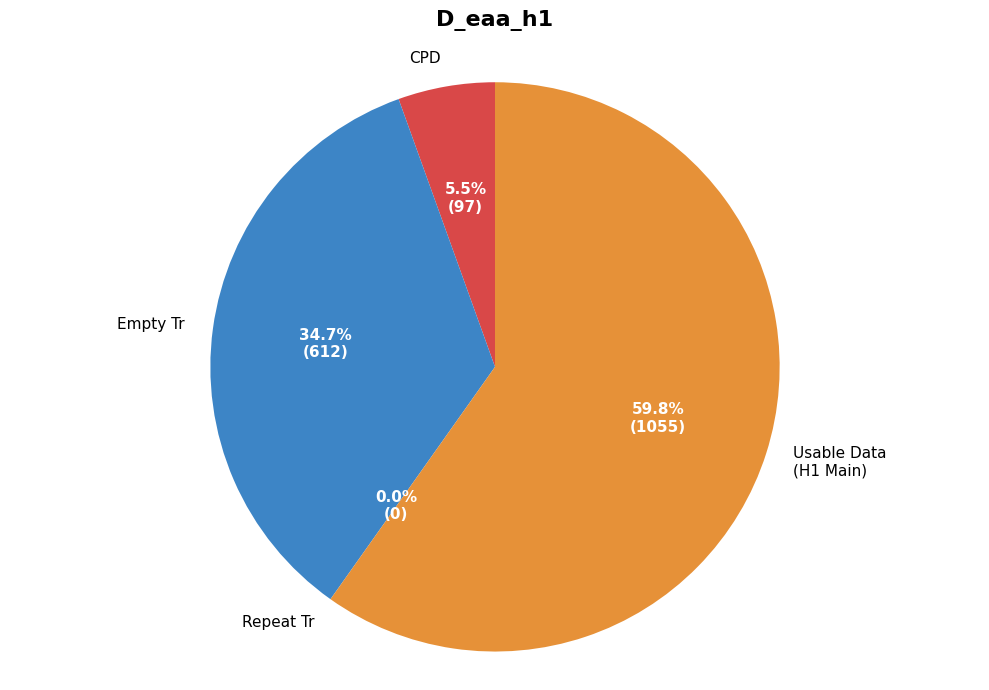

In [250]:
import matplotlib.pyplot as plt

# data
categories = ['CPD', 'Empty Tr', 'Repeat Tr', 'Usable Data\n(H1 Main)']
values = [len(df_cpd), len(df_pure_empty), len(df_repeated), len(df)]

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 7))

# Create the pie chart with customizations
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=['#d94848', '#3d85c6', "#ff36a5", '#e69138'],
    textprops={'fontsize': 11}
)

# Enhance the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add title
plt.title(f'D_{dataset[0:3]}_h1', fontsize=16, fontweight='bold', pad=20)

# Equal aspect ratio ensures circular pie
ax.axis('equal')

plt.tight_layout()

for i in range(len(values)):
    print(f"{categories[i]}: {values[i]}")

In [251]:
list(df)


['Title',
 'Creator',
 'Contributors',
 'Extent',
 'Date',
 'Source',
 'Subject',
 'Description',
 'Digital Collection',
 'Website',
 'Contributing Institution',
 'Rights',
 'Time Period',
 'Geographic Location',
 'Language',
 'Digitization Specifications',
 'Date Digital',
 'Type',
 'Format',
 'Media Type',
 'Identifier',
 'Note',
 'Digital Assistant',
 'OCLC number',
 'Date created',
 'Date modified',
 'Reference URL',
 'CONTENTdm number',
 'CONTENTdm file name',
 'CONTENTdm file path',
 'Year',
 'Original Transcript',
 'Original Len',
 'Special Pattern',
 'General Pattern',
 'Repeat Chars',
 'Short/No Transcript',
 'Quality',
 'Issue Types',
 'Detected Artifacts',
 'D_eaa_cleaned_v1',
 'sc_v1_len',
 'D_eaa_cleaned_v2',
 'sc_v2_len']

## H2

In [252]:
import pandas as pd
import numpy as np
import re, nltk, csv, os
from nltk.corpus import words, PlaintextCorpusReader
import matplotlib.pyplot as plt

# # nltk base
# nltk.download('words')
# english_vocab = set(w.lower() for w in words.words())

In [253]:
import os
os.makedirs(f"../data/{dataset}/split_data/h1_split/", exist_ok=True)
df = pd.read_csv(f"../data/{dataset}/split_data/h1_split/D_{dataset[0:3]}_h1_main.csv")

print(f"df len: {len(df)}")
print(list(df))


# improved ntlk corpus
wordslist = PlaintextCorpusReader('../data/mccray/nltk', 'combined_words_corpus.txt')
english_vocab = set(w.lower() for w in wordslist.words())

def save_csv(df, title):
    df.to_csv(title,
          index=False,
          encoding='utf-8',
          quoting=csv.QUOTE_NONNUMERIC,   
          escapechar='\\',
          lineterminator='\n')

print(len(df))

df len: 1055
['Title', 'Creator', 'Contributors', 'Extent', 'Date', 'Source', 'Subject', 'Description', 'Digital Collection', 'Website', 'Contributing Institution', 'Rights', 'Time Period', 'Geographic Location', 'Language', 'Digitization Specifications', 'Date Digital', 'Type', 'Format', 'Media Type', 'Identifier', 'Note', 'Digital Assistant', 'OCLC number', 'Date created', 'Date modified', 'Reference URL', 'CONTENTdm number', 'CONTENTdm file name', 'CONTENTdm file path', 'Year', 'Original Transcript', 'Original Len', 'Special Pattern', 'General Pattern', 'Repeat Chars', 'Short/No Transcript', 'Quality', 'Issue Types', 'Detected Artifacts', 'D_eaa_cleaned_v1', 'sc_v1_len', 'D_eaa_cleaned_v2', 'sc_v2_len']
1055


In [254]:
title = 'Title'
descrip = 'Description'

# Function to apply re pattern
def re_pattern(text, pattern):
    text = re.sub(r'\s+', '', str(text))
    if not isinstance(text, str) or len(text) == 0:
        return 0
    total = len(text)
    matches = len(pattern.findall(text))
    return (matches / total) * 100

# patterns
# alphanum_standard = re.compile(r'[a-zA-Z0-9\s.,!?;:\'"()\-_/]')
alphanum_standard = re.compile(r'[a-zA-Z0-9!-/:-@[-`{-~]')
alpha_only = re.compile(r'[a-zA-Z]')

# return percent numeric over total alphanum + standard chars
def percent_num(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0
    total_alphanum = len(alphanum_standard.findall(text))
    if total_alphanum == 0:
        return 0
    total_numeric = len(re.findall(r'[0-9]', text))
    return (total_numeric / total_alphanum) * 100

# common suffixes for trimming
# edit this to account for inflectional and derivational
suffixes = {
    # INFLECTIONAL SUFFIXES
    # Plural forms
    "s": True,
    "es": True,
    "ies": True,      
    "ves": True,      
    
    # Verb forms (tense/aspect)
    "ed": True,       # walk -> walked
    "ing": True,      # walk -> walking
    
    # Comparative/Superlative
    "er": True,       # fast -> faster
    "est": True,      # fast -> fastest
    
    # DERIVATIONAL SUFFIXES (word-forming) 
    # Adjective to Adverb
    "ly": True,       # quick -> quickly
    
    # Adjective/Verb to Noun
    "ness": True,     # happy -> happiness
    "ment": True,     # govern -> government
    "tion": True,     # create -> creation
    "sion": True,     # expand -> expansion
    "ity": True,      # real -> reality
    "ty": True,       # certain -> certainty
    "ance": True,     # perform -> performance
    "ence": True,     # differ -> difference
    "ancy": True,     # vacant -> vacancy
    "ency": True,     # fluent -> fluency
    "dom": True,      # king -> kingdom
    "ship": True,     # friend -> friendship
    "hood": True,     # child -> childhood
    "age": True,      # break -> breakage
    "al": True,       # refuse -> refusal
    "ure": True,      # fail -> failure
    
    # Noun/Verb to adjective
    "ous": True,      # danger -> dangerous
    "ious": True,     # glory -> glorious
    "ful": True,      # care -> careful
    "less": True,     # care -> careless
    "able": True,     # read -> readable
    "ible": True,     # sense -> sensible
    "ive": True,      # act -> active
    "ic": True,       # base -> basic
    "ical": True,     # history -> historical
    "ish": True,      # child -> childish
    "like": True,     # life -> lifelike
    "y": True,        # dirt -> dirty
    
    # Verb-forming
    "ize": True,      # modern -> modernize
    "fy": True,       # class -> classify
    "ate": True,      # active -> activate
    "en": True,       # dark -> darken
    
    # Noun-forming 
    "or": True,       # act -> actor
    "ist": True,      # art -> artist
    "ian": True,      # music -> musician
    "ant": True,      # assist -> assistant
    "ent": True,      # study -> student
}

# english metrics with nltk corpus + additional checks
def english_nltk_metrics(text, vocab):
    """Return dict showing which tokens are recognized or not (NLTK-style regex)."""
    if not isinstance(text, str) or not text.strip() or len(text) == 0:
        return {"valid_words": [], "not_words": [], "word_count": 0, "valid_word_count": 0, "percentage": 0, "total_chars_count_from_valid_words": 0, "number_of_words_gt_3": 0}
    # tokenize text into words (using only alphabetic characters, min length 2)
    tokens = re.findall(r"[A-Za-z]{2,}", text.lower())
    # calculate metrics
    word_count = len(tokens)
    num_words_gt_3 = 0
    valid_words, not_words = [], []
    total_chars_count_from_valid_words = 0
    # check each token
    for t in tokens:      
        if t in vocab: 
            valid_words.append(t)
            total_chars_count_from_valid_words = total_chars_count_from_valid_words + len(t)
            if len(t) > 3:
                num_words_gt_3 += 1
        else:
            found_variant = False
            if len(t) > 3: 
                for i in range(4, 0, -1): # check suffixes of length 4 to 1
                    stem = t[:-i]
                    suffix = t[-i:]
                    if suffixes.get(suffix) and len(stem) >= 3:
                        if stem in vocab or (stem + "y") in vocab or (stem + "e") in vocab:
                            valid_words.append(t)
                            total_chars_count_from_valid_words += len(t)
                            found_variant = True
                            if len(t) > 3:
                                num_words_gt_3 += 1
                            break # exit suffix loop
            if not found_variant:
                not_words.append(t)
    # final calculations
    valid_word_count = len(valid_words)
    if len(tokens) == 0:
        percentage = 0
    else:
        percentage = 100 * len(valid_words) / len(tokens)
    return {"valid_words": valid_words, "not_words": not_words, "word_count":word_count, "valid_word_count":valid_word_count, "percentage": percentage, "total_chars_count_from_valid_words": total_chars_count_from_valid_words, "number_of_words_gt_3": num_words_gt_3}


In [255]:
# Title 
df['% alphanum_standard title'] = df[title].apply(lambda x: re_pattern(x, alphanum_standard))
df['% alpha_only title'] = df[title].apply(lambda x: re_pattern(x, alpha_only))
df['% en title'] = df[title].apply(lambda x: english_nltk_metrics(x, english_vocab).get("percentage"))

# Description
df['% alphanum_standard descrip'] = df[descrip].apply(lambda x: re_pattern(x, alphanum_standard))
df['% alpha_only descrip'] = df[descrip].apply(lambda x: re_pattern(x, alpha_only))
df['% en descrip'] = df[descrip].apply(lambda x: english_nltk_metrics(x, english_vocab).get("percentage"))

In [256]:
# Transcripts
og_tr = "Original Transcript"
sc_tr_v1 = f'D_{dataset[0:3]}_cleaned_v1'
sc_tr_v2 = f'D_{dataset[0:3]}_cleaned_v2'

# alphanumeric + ascii symbols
df[f'% alphanum_standard D_{dataset[0:3]}_raw tr'] = df[og_tr].apply(lambda x: re_pattern(x, alphanum_standard))
df[f'% alphanum_standard D_{dataset[0:3]}_cleaned_v1 tr'] = df[sc_tr_v1].apply(lambda x: re_pattern(x, alphanum_standard))
df[f'% alphanum_standard D_{dataset[0:3]}_cleaned_v2 tr'] = df[sc_tr_v2].apply(lambda x: re_pattern(x, alphanum_standard))

# alphabet a-Z
df[f'% alpha_only D_{dataset[0:3]}_raw tr'] = df[og_tr].apply(lambda x: re_pattern(x, alpha_only))
df[f'% alpha_only D_{dataset[0:3]}_cleaned_v1 tr'] = df[sc_tr_v1].apply(lambda x: re_pattern(x, alpha_only))
df[f'% alpha_only D_{dataset[0:3]}_cleaned_v2 tr'] = df[sc_tr_v2].apply(lambda x: re_pattern(x, alpha_only))

# num 0-9 over alphanumeric + ascii symbols
df[f'% num D_{dataset[0:3]}_raw tr'] = df[og_tr].apply(lambda x: percent_num(x))
df[f'% num D_{dataset[0:3]}_cleaned_v1 tr'] = df[sc_tr_v1].apply(lambda x: percent_num(x))
df[f'% num D_{dataset[0:3]}_cleaned_v2 tr'] = df[sc_tr_v2].apply(lambda x: percent_num(x))

# More advanced word checks
df[['og_valid_words', 'og_not_words', 'og_word_count', 'og_valid_word_count', 'og_percentage', 'og_total_chars_count_from_valid_words', "number_words_gt_3"]] = df[og_tr].apply(
    lambda text: pd.Series(english_nltk_metrics(text, english_vocab))
)

df[['sc_v1_valid_words', 'sc_v1_not_words', 'sc_v1_word_count', 'sc_v1_valid_word_count', 'sc_v1_percentage', 'sc_v1_total_chars_count_from_valid_words', "number_words_gt_3"]] = df[sc_tr_v1].apply(
    lambda text: pd.Series(english_nltk_metrics(text, english_vocab))
)

df[['sc_v2_valid_words', 'sc_v2_not_words', 'sc_v2_word_count', 'sc_v2_valid_word_count', 'sc_v2_percentage', 'sc_v2_total_chars_count_from_valid_words', "number_words_gt_3"]] = df[sc_tr_v2].apply(
    lambda text: pd.Series(english_nltk_metrics(text, english_vocab))
)

df['max_word_count_value'] = df[['og_word_count', 'sc_v1_word_count', 'sc_v2_word_count']].max(axis=1)

# Calculate each version's valid word count as percentage of max
df['% og_valid_words'] = df.apply(
    lambda row: (row['og_valid_word_count'] / row['max_word_count_value'] * 100) 
    if row['max_word_count_value'] != 0 else 0, axis=1
)
df['% sc_v1_valid_words'] = df.apply(
    lambda row: (row['sc_v1_valid_word_count'] / row['max_word_count_value'] * 100) 
    if row['max_word_count_value'] != 0 else 0, axis=1
)
df['% sc_v2_valid_words'] = df.apply(
    lambda row: (row['sc_v2_valid_word_count'] / row['max_word_count_value'] * 100) 
    if row['max_word_count_value'] != 0 else 0, axis=1
)

# Calculate Chars in Valid Words Percentage (valid word chars / total char count)
df['og_valid_words_char_percentage'] = df.apply(
    lambda row: (row['og_total_chars_count_from_valid_words'] / row['Original Len'] * 100) 
    if row['Original Len'] != 0 else 0, axis=1
)
df['sc_v1_valid_words_chars_percentage'] = df.apply(
    lambda row: (row['sc_v1_total_chars_count_from_valid_words'] / row['sc_v1_len'] * 100) 
    if row['sc_v1_len'] != 0 else 0, axis=1
)
df['sc_v2_valid_words_chars_percentage'] = df.apply(
    lambda row: (row['sc_v2_total_chars_count_from_valid_words'] / row['sc_v2_len'] * 100) 
    if row['sc_v2_len'] != 0 else 0, axis=1
)

# Calculate Chars in Valid Words Percentage (valid word chars / alpha only chars count)
df['og_alpha_count'] = df[og_tr].apply(lambda x: len(alpha_only.findall(str(x))))
df['og_valid_words_alphachars_percentage'] = df.apply(
    lambda row: (row['og_total_chars_count_from_valid_words'] / row['og_alpha_count'] * 100) 
    if row['og_alpha_count'] != 0 else 0, axis=1
)

df['sc_v1_alpha_count'] = df[sc_tr_v1].apply(lambda x: len(alpha_only.findall(str(x))))
df['sc_v1_valid_words_alphachars_percentage'] = df.apply(
    lambda row: (row['sc_v1_total_chars_count_from_valid_words'] / row['sc_v1_alpha_count'] * 100) 
    if row['sc_v1_alpha_count'] != 0 else 0, axis=1
)

df['sc_v2_alpha_count'] = df[sc_tr_v2].apply(lambda x: len(alpha_only.findall(str(x))))
df['sc_v2_valid_words_alphachars_percentage'] = df.apply(
    lambda row: (row['sc_v2_total_chars_count_from_valid_words'] / row['sc_v2_alpha_count'] * 100) 
    if row['sc_v2_alpha_count'] != 0 else 0, axis=1
)

In [257]:
df[0:10]

,Title,Creator,Contributors,Extent,Date,Source,Subject,Description,Digital Collection,Website,...,% sc_v2_valid_words,og_valid_words_char_percentage,sc_v1_valid_words_chars_percentage,sc_v2_valid_words_chars_percentage,og_alpha_count,og_valid_words_alphachars_percentage,sc_v1_alpha_count,sc_v1_valid_words_alphachars_percentage,sc_v2_alpha_count,sc_v2_valid_words_alphachars_percentage
0,"Letter, 1954 January 17, W.L. Foxworth Sr. to ...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,98.148148,83.713355,84.818482,83.713355,276,93.115942,274,93.795620,276,93.115942
1,"Postcard, 1954 January 20, President M. Citron...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,92.000000,75.903614,77.777778,75.903614,143,88.111888,143,88.111888,143,88.111888
2,"Flyer, no date, announcing the hiring of a ger...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,90.789474,79.952267,79.952267,79.952267,394,85.025381,394,85.025381,394,85.025381
3,"Letter, 1954 January 28, Rev. H.R. Hughes to A...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,90.610329,76.358930,77.157803,76.490925,1024,86.425781,1021,86.679726,1024,86.425781
4,"Letter, 1954 February 10, Rembert Stokes of Pa...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,88.148148,73.923445,76.390606,74.100719,758,81.530343,743,83.176312,758,81.530343
5,"Booklet, no date, Youth Congress Songs of the ...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,75.000000,44.444444,64.000000,44.444444,27,59.259259,23,69.565217,27,59.259259
6,"Booklet, no date, Youth Congress Songs of the ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,95.943563,85.590891,87.218650,86.268302,2324,93.803787,2302,94.265856,2324,93.803787
7,"Booklet, no date, Youth Congress Songs of the ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,92.066806,79.855791,82.865169,80.326383,1975,89.721519,1963,90.168110,1975,89.721519
8,"Booklet, no date, Youth Congress Songs of the ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,96.311475,86.498650,87.284287,87.007696,2038,94.308145,2037,94.354443,2038,94.308145
9,"Booklet, no date, Youth Congress Songs of the ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,96.308725,89.076246,90.401786,89.403974,1278,95.070423,1267,95.895817,1278,95.070423


In [258]:
# Averages
def column_stats(df, colname):
    """
    Returns basic statistics (min, mean, median, max, percentiles) for a numeric column.
    """
    if colname not in df.columns:
        raise ValueError(f"Column '{colname}' not found in DataFrame.")
    
    # Drop NaN values to avoid errors
    series = pd.to_numeric(df[colname], errors='coerce').dropna()

    if series.empty:
        return {"min": None, "p10": None, "p25": None, "mean": None, "median": None, "max": None, "p95": None, "p75": None, "p90": None}
    
    stats = {
        "min": series.min(),
        "p10": series.quantile(0.10),
        "p25": series.quantile(0.25),
        "p75": series.quantile(0.75),
        "p90": series.quantile(0.90),
        "p95": series.quantile(0.95),
        "mean": series.mean(),
        "median": series.median(),
        "max": series.max()
    }
    
    print(f"\nStats for column: **{colname}**")
    print("-" * 40)
    print(f"Minimum:        {stats['min']:.2f}")
    print(f"10th percentile: {stats['p10']:.2f}")
    print(f"25th percentile: {stats['p25']:.2f}")
    print(f"Mean:           {stats['mean']:.2f}")
    print(f"Median:         {stats['median']:.2f}")
    print(f"75th percentile: {stats['p75']:.2f}")
    print(f"90th percentile: {stats['p90']:.2f}")
    print(f"95th percentile: {stats['p95']:.2f}")
    print(f"Maximum:        {stats['max']:.2f}")

    print("-" * 40)

    return stats

check_cols = [
    "% alphanum_standard title",
    "% alpha_only title",
    "% en title",
    "% alphanum_standard descrip",
    "% alpha_only descrip",
    "% en descrip",
    f"% alphanum_standard D_{dataset[0:3]}_raw tr",
    f"% alphanum_standard D_{dataset[0:3]}_cleaned_v1 tr",
    f"% alphanum_standard D_{dataset[0:3]}_cleaned_v2 tr",
    f"% alpha_only D_{dataset[0:3]}_raw tr",
    f"% alpha_only D_{dataset[0:3]}_cleaned_v1 tr",
    f"% alpha_only D_{dataset[0:3]}_cleaned_v2 tr",
    f"% num D_{dataset[0:3]}_raw tr",
    f"% num D_{dataset[0:3]}_cleaned_v1 tr",
    f"% num D_{dataset[0:3]}_cleaned_v2 tr",
    '% og_valid_words',
    '% sc_v1_valid_words',
    '% sc_v2_valid_words',
    'og_valid_words_char_percentage',
    'sc_v1_valid_words_chars_percentage',
    'sc_v2_valid_words_chars_percentage',
    'og_valid_words_alphachars_percentage',
    'sc_v1_valid_words_alphachars_percentage',
    'sc_v2_valid_words_alphachars_percentage'
]

for col in check_cols:
    column_stats(df, col)


Stats for column: **% alphanum_standard title**
----------------------------------------
Minimum:        100.00
10th percentile: 100.00
25th percentile: 100.00
Mean:           100.00
Median:         100.00
75th percentile: 100.00
90th percentile: 100.00
95th percentile: 100.00
Maximum:        100.00
----------------------------------------

Stats for column: **% alpha_only title**
----------------------------------------
Minimum:        72.73
10th percentile: 82.61
25th percentile: 85.88
Mean:           88.17
Median:         88.41
75th percentile: 90.91
90th percentile: 92.74
95th percentile: 94.94
Maximum:        98.29
----------------------------------------

Stats for column: **% en title**
----------------------------------------
Minimum:        82.35
10th percentile: 93.75
25th percentile: 100.00
Mean:           98.74
Median:         100.00
75th percentile: 100.00
90th percentile: 100.00
95th percentile: 100.00
Maximum:        100.00
----------------------------------------

Stat

In [259]:
df[0:10]

,Title,Creator,Contributors,Extent,Date,Source,Subject,Description,Digital Collection,Website,...,% sc_v2_valid_words,og_valid_words_char_percentage,sc_v1_valid_words_chars_percentage,sc_v2_valid_words_chars_percentage,og_alpha_count,og_valid_words_alphachars_percentage,sc_v1_alpha_count,sc_v1_valid_words_alphachars_percentage,sc_v2_alpha_count,sc_v2_valid_words_alphachars_percentage
0,"Letter, 1954 January 17, W.L. Foxworth Sr. to ...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,98.148148,83.713355,84.818482,83.713355,276,93.115942,274,93.795620,276,93.115942
1,"Postcard, 1954 January 20, President M. Citron...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,92.000000,75.903614,77.777778,75.903614,143,88.111888,143,88.111888,143,88.111888
2,"Flyer, no date, announcing the hiring of a ger...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,90.789474,79.952267,79.952267,79.952267,394,85.025381,394,85.025381,394,85.025381
3,"Letter, 1954 January 28, Rev. H.R. Hughes to A...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,90.610329,76.358930,77.157803,76.490925,1024,86.425781,1021,86.679726,1024,86.425781
4,"Letter, 1954 February 10, Rembert Stokes of Pa...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,88.148148,73.923445,76.390606,74.100719,758,81.530343,743,83.176312,758,81.530343
5,"Booklet, no date, Youth Congress Songs of the ...",NaN,NaN,1 item,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,75.000000,44.444444,64.000000,44.444444,27,59.259259,23,69.565217,27,59.259259
6,"Booklet, no date, Youth Congress Songs of the ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,95.943563,85.590891,87.218650,86.268302,2324,93.803787,2302,94.265856,2324,93.803787
7,"Booklet, no date, Youth Congress Songs of the ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,92.066806,79.855791,82.865169,80.326383,1975,89.721519,1963,90.168110,1975,89.721519
8,"Booklet, no date, Youth Congress Songs of the ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,96.311475,86.498650,87.284287,87.007696,2038,94.308145,2037,94.354443,2038,94.308145
9,"Booklet, no date, Youth Congress Songs of the ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Eugene Avery Adams papers, 1892-1968",NaN,...,96.308725,89.076246,90.401786,89.403974,1278,95.070423,1267,95.895817,1278,95.070423


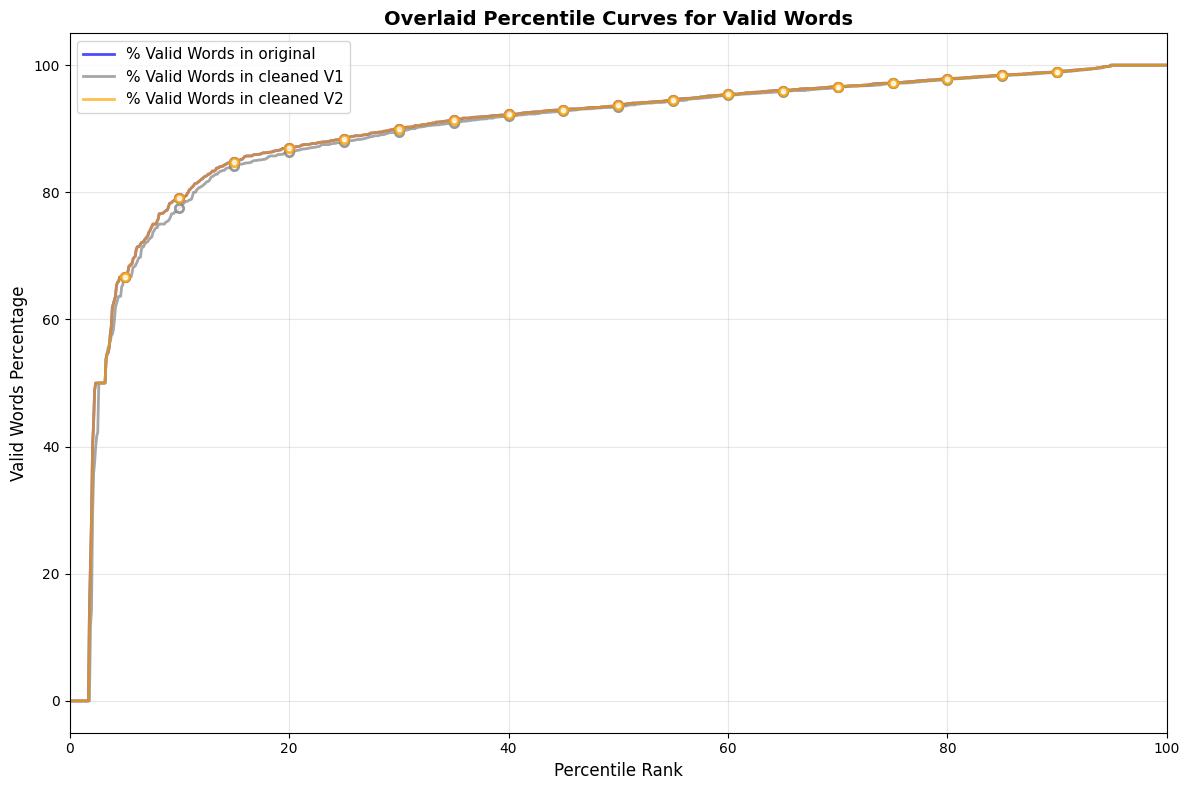

In [260]:
# PERCENTILE PLOTS 
# == PERC OF VALID WORDS ===
# Get the actual data from the DataFrame
og_data = df['% og_valid_words'].dropna().sort_values()
sc_v1_data = df['% sc_v1_valid_words'].dropna().sort_values()
sc_v2_data = df['% sc_v2_valid_words'].dropna().sort_values()

# Calculate percentiles for each dataset
percentiles_to_plot = np.arange(5, 95, 5)

# Create single plot instead of subplots
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

datasets = [
    (og_data, '% Valid Words in original', 'blue'),
    (sc_v1_data, '% Valid Words in cleaned V1', 'gray'),
    (sc_v2_data, '% Valid Words in cleaned V2', 'orange')
]

for data, label, color in datasets:
    # Create x-axis as percentile ranks
    x_percentiles = np.linspace(0, 100, len(data))
    
    # Plot the sorted data
    ax.plot(x_percentiles, data.values, color=color, alpha=0.7, linewidth=2, label=label)
    
    # Calculate and plot percentile markers
    percentile_values = np.percentile(data, percentiles_to_plot)
    
    # Plot percentile markers with same color but different marker
    ax.plot(percentiles_to_plot, percentile_values, 'o', color=color, markersize=6, 
            markerfacecolor='white', markeredgecolor=color, markeredgewidth=2,
            alpha=0.8)

# Customize the plot

ax.set_xlabel("Percentile Rank", fontsize=12)
ax.set_ylabel("Valid Words Percentage", fontsize=12)
ax.set_title("Overlaid Percentile Curves for Valid Words", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()



In [261]:
# Separate out rows based on criteria
# num_sep = rows with % num D_{dataset[0:3]}_raw tr > 50, at least 2 valid word found from original transcript, and at least 1 word with greater than 3 characters
num_sep = df[
    (df[f"% num D_{dataset[0:3]}_raw tr"] > 50) &
    (df[f'number_words_gt_3'] > 0)
]
post_num_sep_df = df[
    (df[f"% num D_{dataset[0:3]}_raw tr"] <= 50) |
    (df[f'number_words_gt_3'] == 0)
]

# r1 = rows with og_valid_words_alphachars_percentage < 50
r1 = post_num_sep_df[
    (post_num_sep_df['og_valid_words_alphachars_percentage'] < 50) 
]
post_r1_df = post_num_sep_df[
    (post_num_sep_df['og_valid_words_alphachars_percentage'] >= 50) 
]
# r2 = rows with og_valid_word_count <= 1
r2 = post_r1_df[
	(post_r1_df['number_words_gt_3'] <= 1)   
]
valid = post_r1_df[
	(post_r1_df['number_words_gt_3'] > 1)   
]

# combine problem rows
problem = pd.concat([r2, r1], ignore_index=True)

# print 
num_sep_count = len(num_sep)
print(f"Len num_sep: {num_sep_count}")
print(f"Len r1 - alpha_char_thresh: {len(r1)}")
print(f"Len r2 - word_count_thresh: {len(r2)}")
print(f"Len problem: {len(problem)}")
print(f"Len valid: {len(valid)}")

Len num_sep: 0
Len r1 - alpha_char_thresh: 36
Len r2 - word_count_thresh: 3
Len problem: 39
Len valid: 1016


In [262]:

# METRICS COLLECTION
# num_sep (print top 2, middle two, bottom 2 rows by % num D_{dataset[0:3]}_raw tr, with the count), print original transcript with them
num_sep_sorted = num_sep.sort_values(by=f'% num D_{dataset[0:3]}_raw tr', ascending=False)
print(f"\nTop 2 num_sep rows by % num D_{dataset[0:3]}_raw tr:")
print(num_sep_sorted[[f'% num D_{dataset[0:3]}_raw tr', 'number_words_gt_3', "CONTENTdm number"]].head(2))
print(f"\nMiddle 2 num_sep rows by % num D_{dataset[0:3]}_raw tr:")
middle_index = len(num_sep_sorted) // 2
print(num_sep_sorted[[f'% num D_{dataset[0:3]}_raw tr', 'number_words_gt_3', "CONTENTdm number"]].iloc[middle_index-1:middle_index+1])
print(f"\nBottom 2 num_sep rows by % num D_{dataset[0:3]}_raw tr:")
print(num_sep_sorted[[f'% num D_{dataset[0:3]}_raw tr', 'number_words_gt_3', "CONTENTdm number"]].tail(2))

# og_valid_words_alphachars_percentage
r1_sorted = r1.sort_values(by='og_valid_words_alphachars_percentage', ascending=False)
print("\nTop 2 valid_words_alphachars rows by og_valid_words_alphachars_percentage:")
print(r1_sorted[['og_valid_words_alphachars_percentage', 'number_words_gt_3', "CONTENTdm number"]].head(2))
print("\nMiddle 2 valid_words_alphachars rows by og_valid_words_alphachars_percentage:")
middle_index = len(r1_sorted) // 2
print(r1_sorted[['og_valid_words_alphachars_percentage', 'number_words_gt_3', "CONTENTdm number"]].iloc[middle_index-1:middle_index+1])
print("\nBottom 2 valid_words_alphachars rows by og_valid_words_alphachars_percentage:")
print(r1_sorted[['og_valid_words_alphachars_percentage', 'number_words_gt_3', "CONTENTdm number"]].tail(2))

# # number_words_gt_3
# r2_sorted = r2.sort_values(by='number_words_gt_3', ascending=False)
# print("\nTop 2 num_sep rows by number_words_gt_3:")
# print(r2_sorted[['number_words_gt_3', 'og_valid_words_alphachars_percentage', "CONTENTdm number"]].head(2))
# print("\nMiddle 2 num_sep rows by number_words_gt_3:")
# middle_index = len(r2_sorted) // 2
# print(r2_sorted[['number_words_gt_3', 'og_valid_words_alphachars_percentage', "CONTENTdm number"]].iloc[middle_index-1:middle_index+1])
# print("\nBottom 2 num_sep rows by number_words_gt_3:")
# print(r2_sorted[['number_words_gt_3', 'og_valid_words_alphachars_percentage', "CONTENTdm number"]].tail(2))



Top 2 num_sep rows by % num D_eaa_raw tr:
Empty DataFrame
Columns: [% num D_eaa_raw tr, number_words_gt_3, CONTENTdm number]
Index: []

Middle 2 num_sep rows by % num D_eaa_raw tr:
Empty DataFrame
Columns: [% num D_eaa_raw tr, number_words_gt_3, CONTENTdm number]
Index: []

Bottom 2 num_sep rows by % num D_eaa_raw tr:
Empty DataFrame
Columns: [% num D_eaa_raw tr, number_words_gt_3, CONTENTdm number]
Index: []

Top 2 valid_words_alphachars rows by og_valid_words_alphachars_percentage:
     og_valid_words_alphachars_percentage  number_words_gt_3  CONTENTdm number
829                             47.222222                  4              1010
620                             45.771144                 13               747

Middle 2 valid_words_alphachars rows by og_valid_words_alphachars_percentage:
     og_valid_words_alphachars_percentage  number_words_gt_3  CONTENTdm number
388                                   0.0                  0               483
389                                 

In [263]:
data_check = df[
    (df['sc_v1_valid_words_alphachars_percentage'] < 50) |
    (df['sc_v1_valid_word_count'] <= 1)   
]
data_check = data_check[['CONTENTdm file name', 'Original Transcript']]

data_check_2 = df[
    (df['sc_v2_valid_words_alphachars_percentage'] < 50) |
    (df['sc_v2_valid_word_count'] <= 1)   
]
data_check_2 = data_check_2[['CONTENTdm file name', 'Original Transcript']]

# less than 50 on og_valid_words_alphachars_percentage is def bad
print("problem len:", len(problem))

problem['text'] = problem['Original Transcript']

check = problem[['CONTENTdm file name', 'text', sc_tr_v2, 'og_valid_words', 'sc_v2_valid_words', '% og_valid_words', '% sc_v2_valid_words']]
print("main problematic examples:")
if view_dataframes:
    display(check)

print("data check v1 (sc_v1_valid_words_alphachars_percentage < 50):")
if view_dataframes:
    display(data_check)
print("data check v2 (sc_v2_valid_words_alphachars_percentage < 50):")
if view_dataframes:
    display(data_check_2)


problem len: 39
main problematic examples:


,CONTENTdm file name,text,D_eaa_cleaned_v2,og_valid_words,sc_v2_valid_words,% og_valid_words,% sc_v2_valid_words
0,44.jp2,Tw^y ^^^\n<0 0,Tw^y ^^^\n<0 0,[tw],[tw],100.000000,100.000000
1,48.jp2,13 it\nJi a si\nt\n^^^,13 it\nJi a si\nt\n^^^,"[it, ji, si]","[it, ji, si]",100.000000,100.000000
2,930.jp2,Z357\n^^ Dee /9^1\nliving in the I lew,Z357\n^^ Dee /9^1\nliving in the I lew,"[dee, living, in, the, lew]","[dee, living, in, the, lew]",100.000000,100.000000
3,47.jp2,8-35^,8-35^,[],[],0.000000,0.000000
4,51.jp2,"Tse?.\nII h\n\n// ""\nH (I\nh\n^l^\t^^\n\n\n\n^...","Tse?.\nII h\n\n// ""\nH (I\nh\n^l^\t^^\n\n\n\n^...","[ii, ma]","[ii, ma]",50.000000,50.000000
5,52.jp2,^2^7,^2^7,[],[],0.000000,0.000000
6,127.jp2,^^^.\n^z2//WZ ^A 2^>tX^f,^^^.\n^z2//WZ ^A 2^>tX^f,[tx],[tx],50.000000,50.000000
7,179.jp2,<5\n3\nX !\n■^ J9 § co a 2\n0> u 8\nX X ♦ i\nX...,<5\n3\nX !\n^ J9 co a 2\n0> u 8\nX X i\nX X X ...,"[co, id]","[co, id]",40.000000,40.000000
8,185.jp2,ess?\n[9-M^^ S(2]\n^^£^2^1^\n-f^+±^-^^^\n^L^c^...,ess?\n[9-M^^ S(2]\n^^ ^2^1^\n-f^+ ^-^^^\n^L^c^...,[ess],[ess],50.000000,50.000000
9,261.jp2,9S6i RdorV\nU.S.POSTAGE,9S6i RdorV\nU.S.POSTAGE,[postage],[postage],50.000000,50.000000


data check v1 (sc_v1_valid_words_alphachars_percentage < 50):


,CONTENTdm file name,Original Transcript
34,44.jp2,Tw^y ^^^\n<0 0
37,47.jp2,8-35^
41,51.jp2,"Tse?.\nII h\n\n// ""\nH (I\nh\n^l^\t^^\n\n\n\n^..."
42,52.jp2,^2^7
92,127.jp2,^^^.\n^z2//WZ ^A 2^>tX^f
141,179.jp2,<5\n3\nX !\n■^ J9 § co a 2\n0> u 8\nX X ♦ i\nX...
147,185.jp2,ess?\n[9-M^^ S(2]\n^^£^2^1^\n-f^+±^-^^^\n^L^c^...
197,261.jp2,9S6i RdorV\nU.S.POSTAGE
209,275.jp2,A\\\nX :\nX3 g 5\nft O o\nCD W 5\nQ O c3 o ft\...
216,282.jp2,SiSf*\n2> N^y f9^\n^c ^fubcnt ^uhg\nnf ±Jtje\n...


data check v2 (sc_v2_valid_words_alphachars_percentage < 50):


,CONTENTdm file name,Original Transcript
34,44.jp2,Tw^y ^^^\n<0 0
37,47.jp2,8-35^
41,51.jp2,"Tse?.\nII h\n\n// ""\nH (I\nh\n^l^\t^^\n\n\n\n^..."
42,52.jp2,^2^7
92,127.jp2,^^^.\n^z2//WZ ^A 2^>tX^f
141,179.jp2,<5\n3\nX !\n■^ J9 § co a 2\n0> u 8\nX X ♦ i\nX...
147,185.jp2,ess?\n[9-M^^ S(2]\n^^£^2^1^\n-f^+±^-^^^\n^L^c^...
197,261.jp2,9S6i RdorV\nU.S.POSTAGE
209,275.jp2,A\\\nX :\nX3 g 5\nft O o\nCD W 5\nQ O c3 o ft\...
216,282.jp2,SiSf*\n2> N^y f9^\n^c ^fubcnt ^uhg\nnf ±Jtje\n...


In [264]:
if save_files:
    path = f"../data/{dataset}/split_data/h2_split"
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)
    if not os.path.exists(f"{path}/subsets"):
        os.makedirs(f"{path}/subsets", exist_ok=True)

    save_csv(problem, f"{path}/D_{dataset[0:3]}_h2_poor (bad transcripts).csv")
    save_csv(num_sep, f"{path}/subsets/D_{dataset[0:3]}_h2_high_number_count (good transcripts subset).csv")
    save_csv(valid, f"{path}/subsets/D_{dataset[0:3]}_h2_main_subset (good transcripts subset).csv")

# find columns where valid words are different between og and v2
diff_valid_words = df[
    (df['og_valid_words'] != df['sc_v2_valid_words'])
]
# create list of which words differ
def list_diff_words(row):
    og_set = set(row['og_valid_words'])
    sc_set = set(row['sc_v2_valid_words'])
    diff_words = og_set.symmetric_difference(sc_set)
    return list(diff_words)

diff_valid_words['diff_valid_words'] = diff_valid_words.apply(list_diff_words, axis=1)
# if save_files:
#     save_csv(diff_valid_words, f"D_{dataset[0:3]}_h2_diff_valid_words.csv")

/var/folders/l3/byyvsw1924df7wl2r_fqdrfh0000gn/T/ipykernel_62585/3851936375.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [265]:
# get sizes from h1 invalid counts (_0, _cpd, _rep)
df_0 = pd.read_csv(f"../data/{dataset}/split_data/h1_split/D_{dataset[0:3]}_empty_transcripts.csv")
df_cpd = pd.read_csv(f"../data/{dataset}/split_data/h1_split/D_{dataset[0:3]}_cpd.csv")
df_rep = pd.read_csv(f"../data/{dataset}/split_data/h1_split/D_{dataset[0:3]}_repeated_transcripts.csv")

df_0_len = len(df_0) 
df_cpd_len = len(df_cpd)
df_rep_len = len(df_rep)

print(df_0_len, df_cpd_len, df_rep_len)

total_h1_invalid_len = df_0_len +  df_cpd_len + df_rep_len
print(total_h1_invalid_len)

612 97 0
709


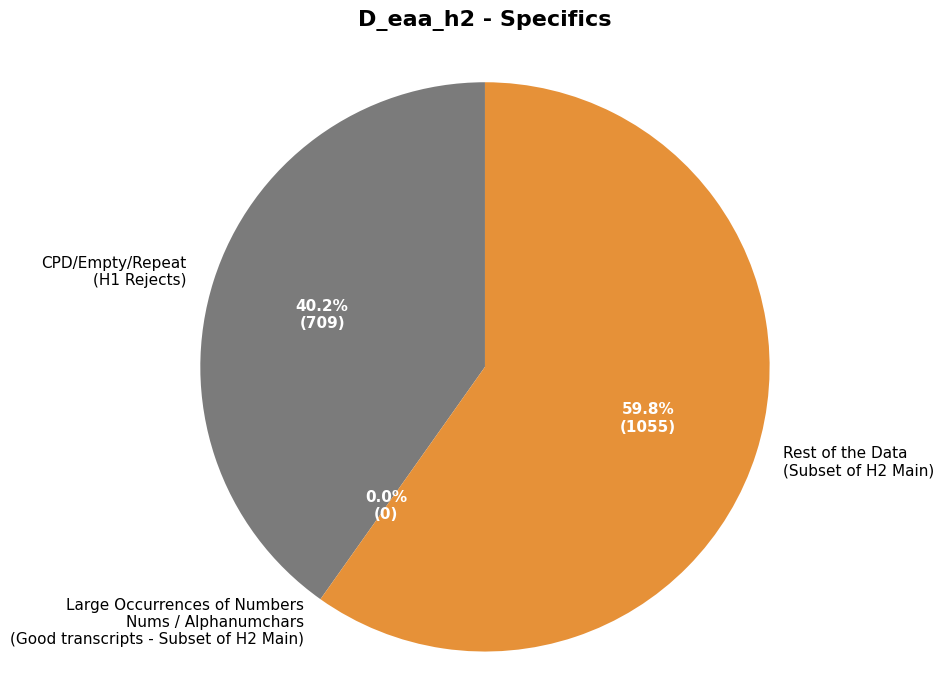

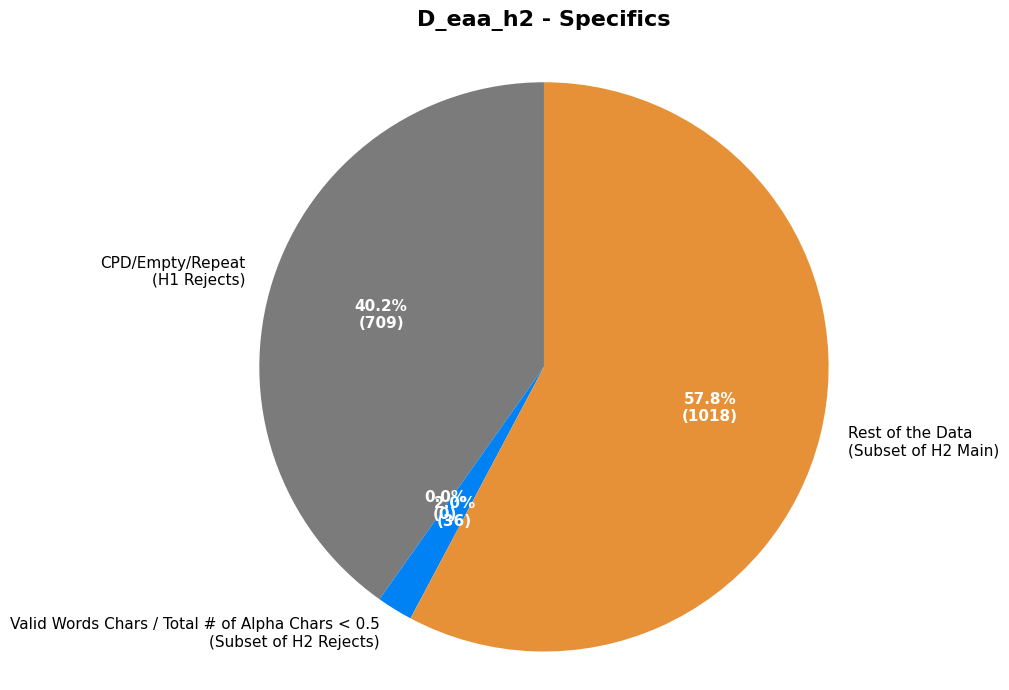

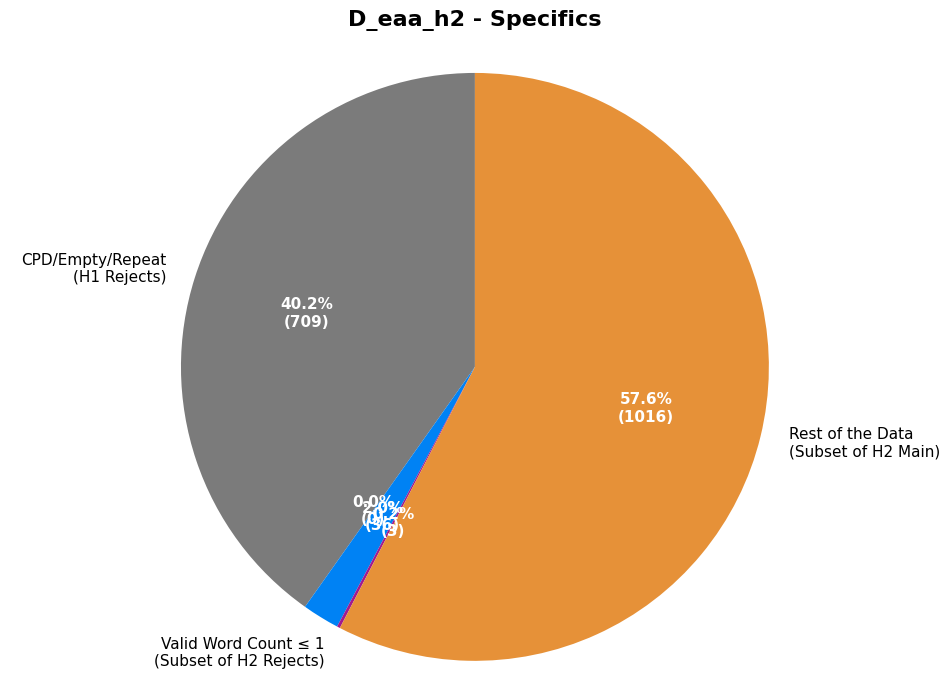

In [266]:
# round 1 = H1
# round 2 pie chart
round_one_iso = total_h1_invalid_len # gray
num_sep_r = num_sep_count  
# num_sep_r = 79  
r2_part_1 = len(r1)
r2_part_2 = len(r2)
rest = len(valid) + r2_part_2 + r2_part_1  # orange

# data
categories = ['CPD/Empty/Repeat\n(H1 Rejects)', 'Large Occurrences of Numbers\nNums / Alphanumchars\n(Good transcripts - Subset of H2 Main)', 'Rest of the Data\n(Subset of H2 Main)']
values = [round_one_iso, num_sep_r, rest]

fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=["#7b7b7b", '#e69138', '#e69138'],
    textprops={'fontsize': 11}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
plt.title(f'D_{dataset[0:3]}_h2 - Specifics', fontsize=16, fontweight='bold', pad=20)
ax.axis('equal')
plt.tight_layout()

# round 4 pie chart

# round 3 pie chart
# num_sep_r = num_sep_count  
r2_part_1 = len(r1)
r2_part_2 = len(r2)
rest = len(valid) + r2_part_2  # orange

# data
# categories = ['CPD/Empty/Repeat\n(H1 Rejects)', 'Large Occurrences of Numbers\nNums / Alphanumchars\n(Good transcripts - Subset of H2 Main)', 'Valid Words Chars / Total # of Alpha Chars < 0.5\n(Subset of H2 Rejects)', 'Rest of the Data\n(Subset of H2 Main)']
categories = ['CPD/Empty/Repeat\n(H1 Rejects)', '', 'Valid Words Chars / Total # of Alpha Chars < 0.5\n(Subset of H2 Rejects)', 'Rest of the Data\n(Subset of H2 Main)']
values = [round_one_iso, num_sep_r, r2_part_1, rest]

fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=["#7b7b7b", '#e69138', "#0082f4", '#e69138'],
    textprops={'fontsize': 11}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
plt.title(f'D_{dataset[0:3]}_h2 - Specifics', fontsize=16, fontweight='bold', pad=20)
ax.axis('equal')
plt.tight_layout()

# round 4 pie chart

# Counts
# num_sep_r = num_sep_count  
r2_part_1 = len(r1)
r2_part_2 = len(r2)
rest = len(valid) # orange

# data
categories = ['CPD/Empty/Repeat\n(H1 Rejects)', 'Large Occurrences of Numbers\nNums / Alphanumchars\n(Good transcripts - Subset of H2 Main)', 'Valid Words Chars / Total # of Alpha Chars < 0.5\n(Subset of H2 Rejects)', 'Valid Word Count ≤ 1\n(Subset of H2 Rejects)', 'Rest of the Data\n(Subset of H2 Main)']
categories = ['CPD/Empty/Repeat\n(H1 Rejects)', '', '', 'Valid Word Count ≤ 1\n(Subset of H2 Rejects)', 'Rest of the Data\n(Subset of H2 Main)']
values = [round_one_iso, num_sep_r, r2_part_1, r2_part_2, rest]

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 7))

# Create the pie chart with customizations
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=["#7b7b7b", '#e69138', "#0082f4", "#a11a8f", '#e69138'],
    textprops={'fontsize': 11}
)

# Enhance the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add title
plt.title(f'D_{dataset[0:3]}_h2 - Specifics', fontsize=16, fontweight='bold', pad=20)

# Equal aspect ratio ensures circular pie
ax.axis('equal')

plt.tight_layout()


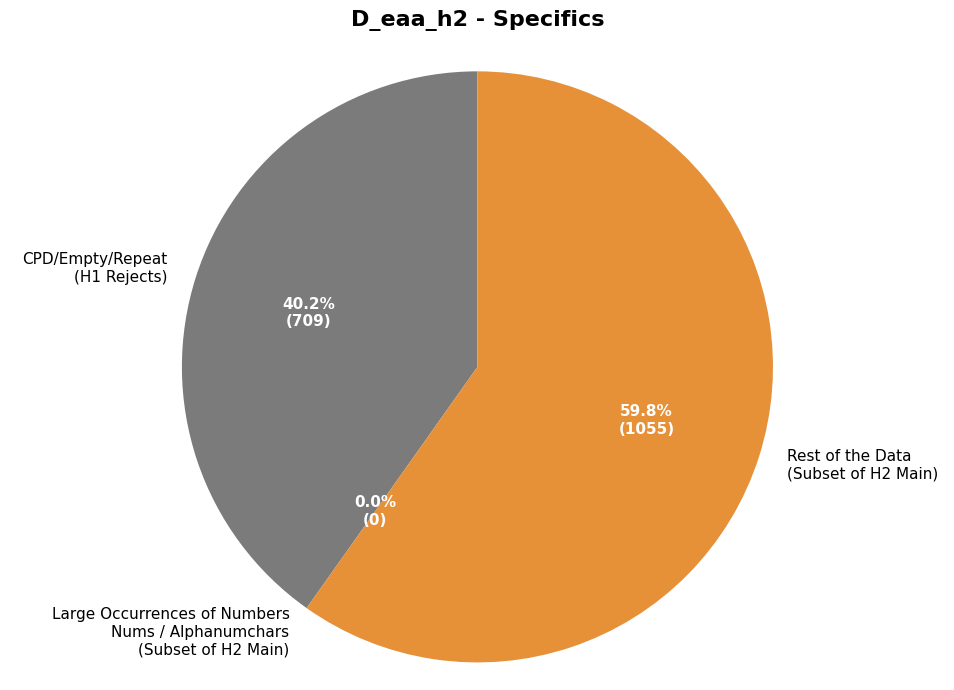

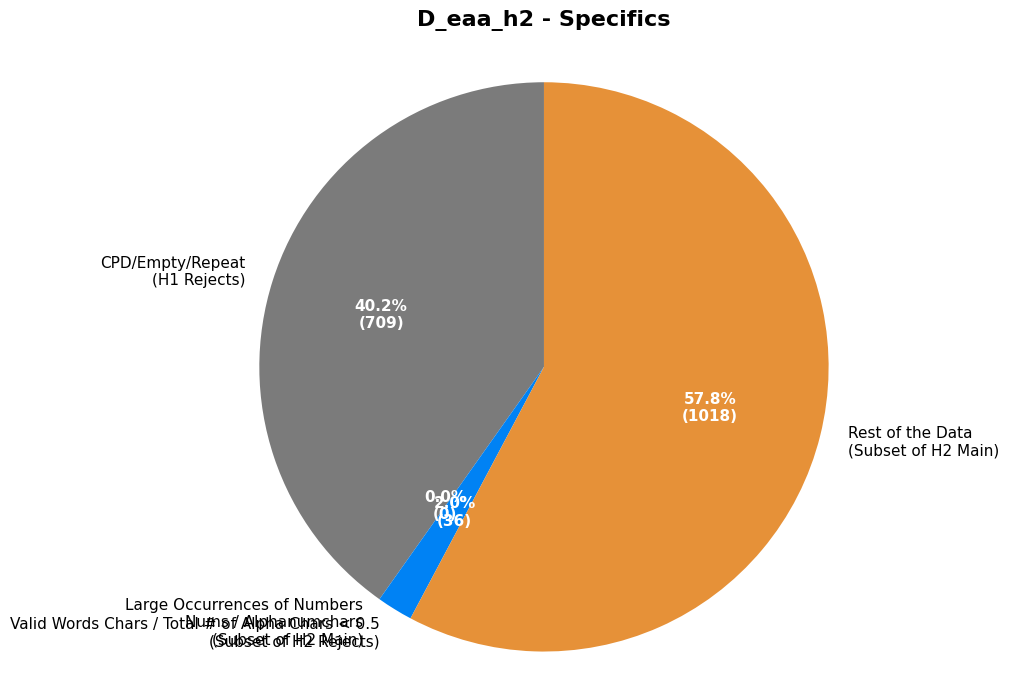

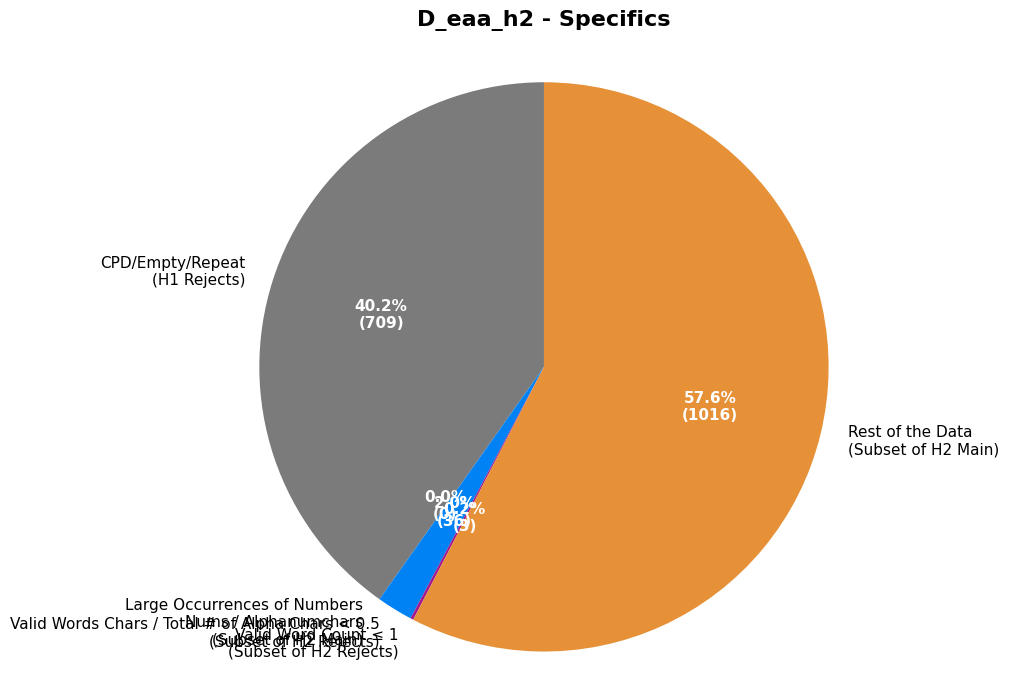

In [267]:
# round 1 = H1
# round 2 pie chart
round_one_iso = total_h1_invalid_len # gray
num_sep_r = num_sep_count  
# num_sep_r = 79  
r2_part_1 = len(r1)
r2_part_2 = len(r2)
rest = len(valid) + r2_part_2 + r2_part_1  # orange

# data
categories = ['CPD/Empty/Repeat\n(H1 Rejects)', 'Large Occurrences of Numbers\nNums / Alphanumchars\n(Subset of H2 Main)', 'Rest of the Data\n(Subset of H2 Main)']
values = [round_one_iso, num_sep_r, rest]

fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=["#7b7b7b", '#e69138', '#e69138'],
    textprops={'fontsize': 11}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
plt.title(f'D_{dataset[0:3]}_h2 - Specifics', fontsize=16, fontweight='bold', pad=20)
ax.axis('equal')
plt.tight_layout()

# round 4 pie chart

# round 3 pie chart
# num_sep_r = num_sep_count  
r2_part_1 = len(r1)
r2_part_2 = len(r2)
rest = len(valid) + r2_part_2  # orange

# data
categories = ['CPD/Empty/Repeat\n(H1 Rejects)', 'Large Occurrences of Numbers\nNums / Alphanumchars\n(Subset of H2 Main)', 'Valid Words Chars / Total # of Alpha Chars < 0.5\n(Subset of H2 Rejects)', 'Rest of the Data\n(Subset of H2 Main)']
values = [round_one_iso, num_sep_r, r2_part_1, rest]

fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=["#7b7b7b", '#e69138', "#0082f4", '#e69138'],
    textprops={'fontsize': 11}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
plt.title(f'D_{dataset[0:3]}_h2 - Specifics', fontsize=16, fontweight='bold', pad=20)
ax.axis('equal')
plt.tight_layout()

# round 4 pie chart

# Counts
# num_sep_r = num_sep_count  
r2_part_1 = len(r1)
r2_part_2 = len(r2)
rest = len(valid) # orange

# data
categories = ['CPD/Empty/Repeat\n(H1 Rejects)', 'Large Occurrences of Numbers\nNums / Alphanumchars\n(Subset of H2 Main)', 'Valid Words Chars / Total # of Alpha Chars < 0.5\n(Subset of H2 Rejects)', 'Valid Word Count ≤ 1\n(Subset of H2 Rejects)', 'Rest of the Data\n(Subset of H2 Main)']
values = [round_one_iso, num_sep_r, r2_part_1, r2_part_2, rest]

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 7))

# Create the pie chart with customizations
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=["#7b7b7b", '#e69138', "#0082f4", "#a11a8f", '#e69138'],
    textprops={'fontsize': 11}
)

# Enhance the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add title
plt.title(f'D_{dataset[0:3]}_h2 - Specifics', fontsize=16, fontweight='bold', pad=20)

# Equal aspect ratio ensures circular pie
ax.axis('equal')

plt.tight_layout()


In [268]:
if save_files:
    path = f"../data/{dataset}/split_data/h2_split/"

    # combine num_sep and main into one
    combined = pd.concat([valid, num_sep], ignore_index=True)
    print(f"Len combined: {len(combined)}")
    save_csv(combined, f"{path}/D_{dataset[0:3]}_h2_main (good transcripts).csv") # main subset + nums

Len combined: 1016


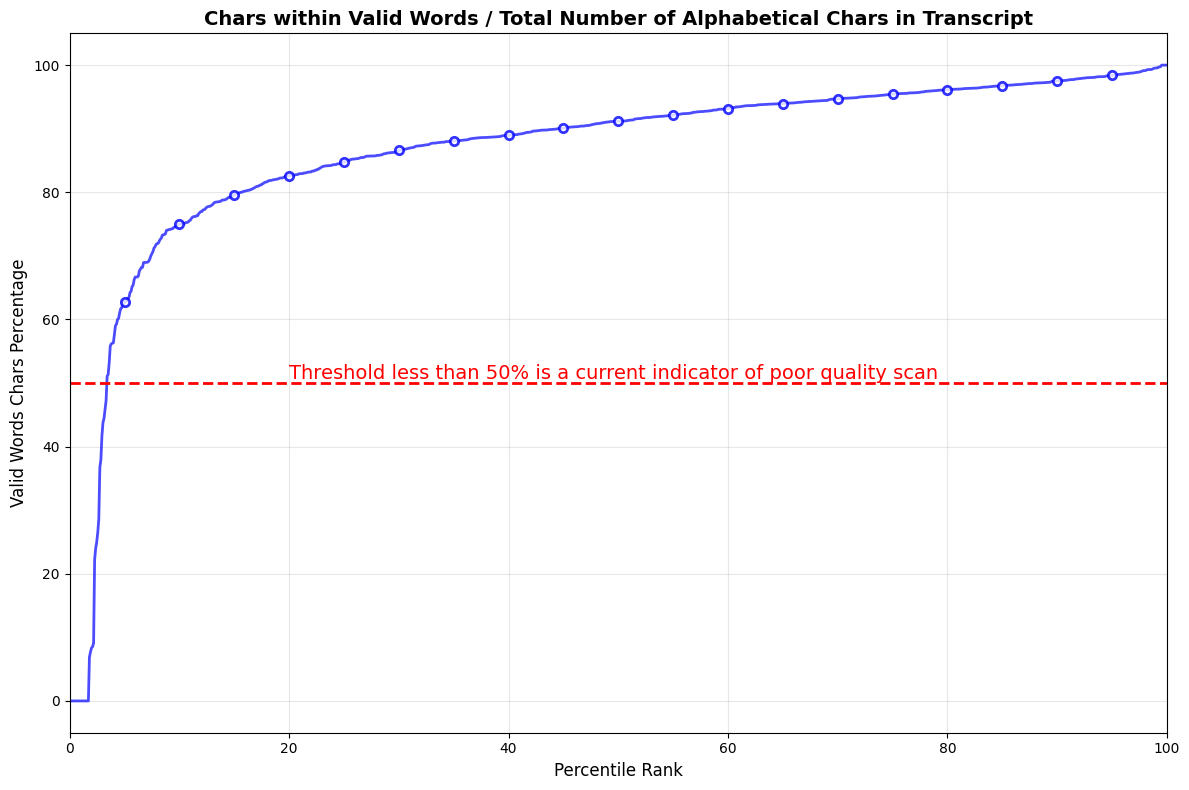

Top 10 rows with lowest number_words_gt_3:
92: ^^^.
^z2//WZ ^A 2^>tX^f
943: ^5?.
V >
LMM
34: Tw^y ^^^
<0 0
38: 13 it
Ji a si
t
^^^
911: Bl. M*
ft ft rr
N
■Q r u i
J0 Ic ?u *1 "
^3
<37 ?*/
* El A>^p *
^ 4/ ^
___: x4^
o
692: ^^1
813: S 0 "J to
o S
P 5s tn
❖ ❖ ❖ ***
♦2*
Y X * $
Y Y Y Y ❖ Y Y Y Y Y Y X * X X
4-4 •-n S*
f^ Y
^^
688: <_..^<-^--v-"
41: Tse?.
II h

// "
H (I
h
^l^	^^



^^^ M' ^^
M^ Yi.^A.t^^ (§MA)^^^^
42: ^2^7


Top 2 rows with lowest og_valid_words_alphachars_percentage:
37: 0.00% - 8-35^
633: 0.00% - 8359

Middle 2 rows:
688: 0.00% - <_..^<-^--v-"
692: 0.00% - ^^1

Bottom 2 rows with highest og_valid_words_alphachars_percentage:
620: 45.77% - r^tt^ h^v* Mesa s^t to th* eoll<r4ng WllborfGre^sns in y-u? bedUy,
Mr* MXlle« Hill, 103 Echola,St* Groonvill'.
nw» Butene A. Mass, SIU Lady St*, Columbia
Mr* Milica Saopson, #f % MMW Av®*, Saaptar
Mrs* Settle W* Robinsoil, 706 8. Moon St*, Flounce
Bishop & Mrs* Frank Rold, Alien OnUeraity, Crumble
829: 47.22% - A. BOULWARE KING, PASTOR

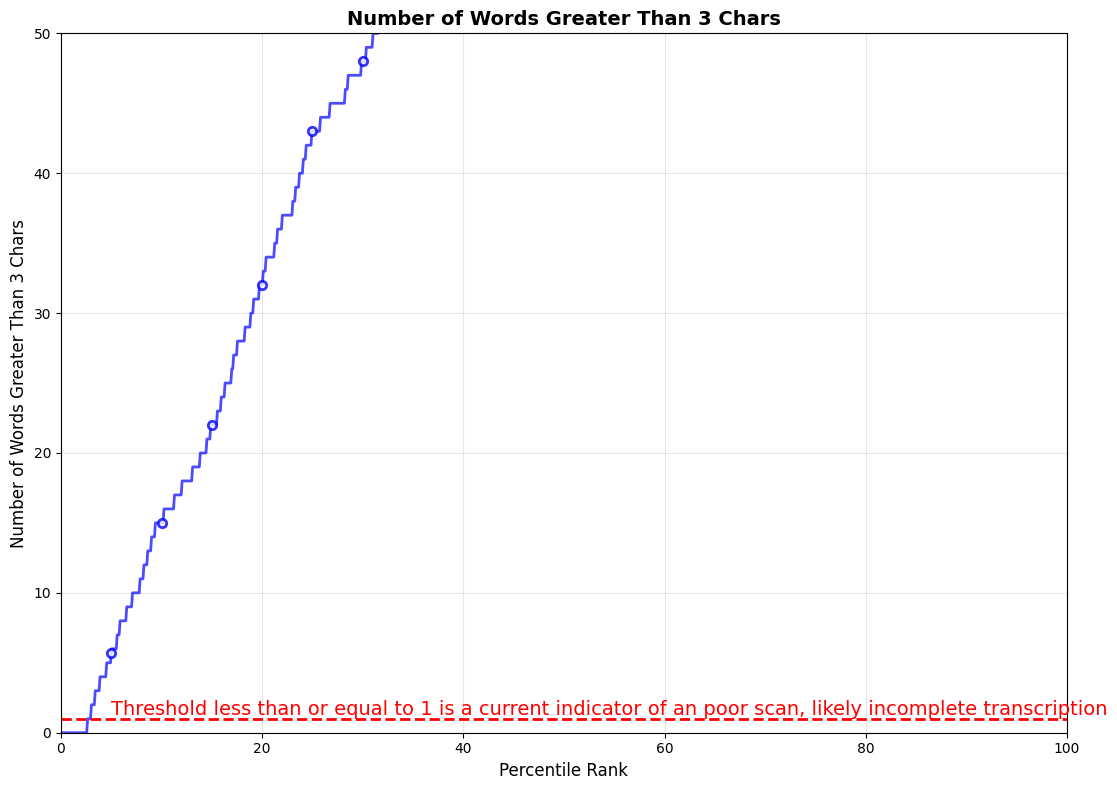

In [269]:
def create_percentile_plot_single(df, col, title, y_label, color, y_intercept, y_intercept_label=None, max_value=None, location_for_y_label=20):
    og_data = df[col].dropna().sort_values()

    # Calculate percentiles for each dataset
    percentiles_to_plot = np.arange(5, 100, 5)

    # Create single plot instead of subplots
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    # Plot the sorted data
    ax.plot(np.linspace(0, 100, len(og_data)), og_data.values, color=color, alpha=0.7, linewidth=2, label=label)
    # Calculate and plot percentile markers
    percentile_values = np.percentile(og_data, percentiles_to_plot)
    # Plot percentile markers with same color but different marker
    ax.plot(percentiles_to_plot, percentile_values, 'o', color='blue', markersize
        =6, markerfacecolor='white', markeredgecolor='blue', markeredgewidth=2,
        alpha=0.8)
    # Customize the plot
    ax.set_xlabel("Percentile Rank", fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.axhline(y=y_intercept, color='red', linestyle='--', linewidth=2)
    if y_intercept_label:
        plt.text(location_for_y_label, y_intercept, y_intercept_label, color='red', fontsize=14, va='bottom', ha='left')
    if max_value:
        ax.set_ylim(0, max_value)
    ax.grid(True, alpha=0.3)
    # ax.legend(fontsize=11)
    ax.set_xlim(0, 100)
    plt.tight_layout()
    plt.show()


create_percentile_plot_single(df, 'og_valid_words_alphachars_percentage', 'Chars within Valid Words / Total Number of Alphabetical Chars in Transcript', 'Valid Words Chars Percentage', 'blue', 50, y_intercept_label='Threshold less than 50% is a current indicator of poor quality scan')

percent_check = df[
    (df['og_valid_words_alphachars_percentage'] < 50)
]

# sort check by number_words_gt_3 ascending
num_check = df.sort_values(by='number_words_gt_3', ascending=True)

# print top 2, middle 2, bottom 2
if view_dataframes:
    # nums
    print("Top 10 rows with lowest number_words_gt_3:")
    for idx, text in num_check.head(10)['Original Transcript'].items():
        print(f"{idx}: {text}")

    # pers
    print("\n\nTop 2 rows with lowest og_valid_words_alphachars_percentage:")
    check_sorted = percent_check.sort_values(by='og_valid_words_alphachars_percentage', ascending=True)
    for idx, row in check_sorted.head(2)[['og_valid_words_alphachars_percentage', 'Original Transcript']].iterrows():
        print(f"{idx}: {row['og_valid_words_alphachars_percentage']:.2f}% - {row['Original Transcript']}")
    
    middle_index = len(check_sorted) // 2
    print("\nMiddle 2 rows:")
    for idx, row in check_sorted.iloc[middle_index-1:middle_index+1][['og_valid_words_alphachars_percentage', 'Original Transcript']].iterrows():
        print(f"{idx}: {row['og_valid_words_alphachars_percentage']:.2f}% - {row['Original Transcript']}")
    
    print("\nBottom 2 rows with highest og_valid_words_alphachars_percentage:")
    for idx, row in check_sorted.tail(2)[['og_valid_words_alphachars_percentage', 'Original Transcript']].iterrows():
        print(f"{idx}: {row['og_valid_words_alphachars_percentage']:.2f}% - {row['Original Transcript']}")

create_percentile_plot_single(df, 'number_words_gt_3', 'Number of Words Greater Than 3 Chars', 'Number of Words Greater Than 3 Chars', 'blue', 1, max_value=50, y_intercept_label='Threshold less than or equal to 1 is a current indicator of an poor scan, likely incomplete transcription', location_for_y_label=5)


## Data Flow Sankey Diagrams

In [270]:
import subprocess
import sys
import plotly.graph_objects as go

# Sankey diagram showing data flow from H1, H2
# Get the row counts
total_raw = len(df_cpd) + len(df_pure_empty) + len(df_repeated) + len(df)
h1_usable = len(df)
h1_rejects = len(df_cpd) + len(df_pure_empty) + len(df_repeated)
h2_usable = len(valid) + len(num_sep)
h2_rejects = len(problem)

# Sankey nodes with counts in labels
nodes = [
    f"Total row count<br>n={total_raw}",
    f"H1: CPD/Collections<br>n={len(df_cpd)}",
    f"H1: Empty/Repeated<br>n={len(df_pure_empty) + len(df_repeated)}",
    f"H1: Usable<br>n={h1_usable}",
    f"H2: Poor Scans<br>n={h2_rejects}",
    f"H2: Usable<br>n={h2_usable}"
]

# Sankey links (source, target, value)
source = [0, 0, 0, 3, 3]
target = [1, 2, 3, 4, 5]
value = [len(df_cpd), len(df_pure_empty) + len(df_repeated), h1_usable, h2_rejects, h2_usable]

# Colors for nodes
node_colors = [
    "rgba(100, 100, 100, 0.8)",  # Raw (gray)
    "rgba(217, 72, 72, 0.8)",    # CPD (red)
    "rgba(255, 54, 165, 0.8)",   # Empty/Repeated (magenta)
    "rgba(230, 145, 56, 0.8)",   # H1 Usable (orange)
    "rgba(0, 130, 244, 0.8)",    # H2 Poor (blue)
    "rgba(230, 145, 56, 0.8)"    # H2 Usable (orange)
]

# Colors for links
link_colors = [
    "rgba(217, 72, 72, 0.4)",
    "rgba(255, 54, 165, 0.4)",
    "rgba(230, 145, 56, 0.4)",
    "rgba(0, 130, 244, 0.4)",
    "rgba(230, 145, 56, 0.4)"
]

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes,
        color=node_colors
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors
    )
)])

fig.update_layout(
    title=f"{dataset.upper()}: Data Flow Raw → H1 → H2",
    font=dict(size=12, family="Arial"),
    height=600,
    width=1000
)

fig.show()

# Detailed breakdown statistics
print("\n" + "="*60)
print(f"DATA STRATIFICATION SUMMARY - {dataset.upper()}")
print("="*60)
print(f"\nRAW DOCUMENTS: {total_raw}")
print(f"├── CPD/Collections: {len(df_cpd)} ({len(df_cpd)/total_raw*100:.1f}%)")
print(f"├── Empty Transcripts: {len(df_pure_empty)} ({len(df_pure_empty)/total_raw*100:.1f}%)")
print(f"├── Repeated Content: {len(df_repeated)} ({len(df_repeated)/total_raw*100:.1f}%)")
print(f"└── H1 USABLE: {h1_usable} ({h1_usable/total_raw*100:.1f}%)")
print(f"\nH2 PROCESSING OF H1 USABLE ({h1_usable}):")
print(f"├── H2 Poor Scans: {h2_rejects} ({h2_rejects/h1_usable*100:.1f}%)")
print(f"│   ├── High Numeric Content: {num_sep_count}")
print(f"│   ├── Low Valid Word Chars: {len(r1)}")
print(f"│   └── Low Word Count: {len(r2)}")
print(f"└── H2 USABLE: {h2_usable} ({h2_usable/h1_usable*100:.1f}%)")
print(f"    ├── Valid Documents: {len(valid)}")
print(f"    └── Numeric-Heavy (Usable): {num_sep_count}")
print("="*60)


DATA STRATIFICATION SUMMARY - EAADAMS

RAW DOCUMENTS: 1764
├── CPD/Collections: 97 (5.5%)
├── Empty Transcripts: 612 (34.7%)
├── Repeated Content: 0 (0.0%)
└── H1 USABLE: 1055 (59.8%)

H2 PROCESSING OF H1 USABLE (1055):
├── H2 Poor Scans: 39 (3.7%)
│   ├── High Numeric Content: 0
│   ├── Low Valid Word Chars: 36
│   └── Low Word Count: 3
└── H2 USABLE: 1016 (96.3%)
    ├── Valid Documents: 1016
    └── Numeric-Heavy (Usable): 0
